🚀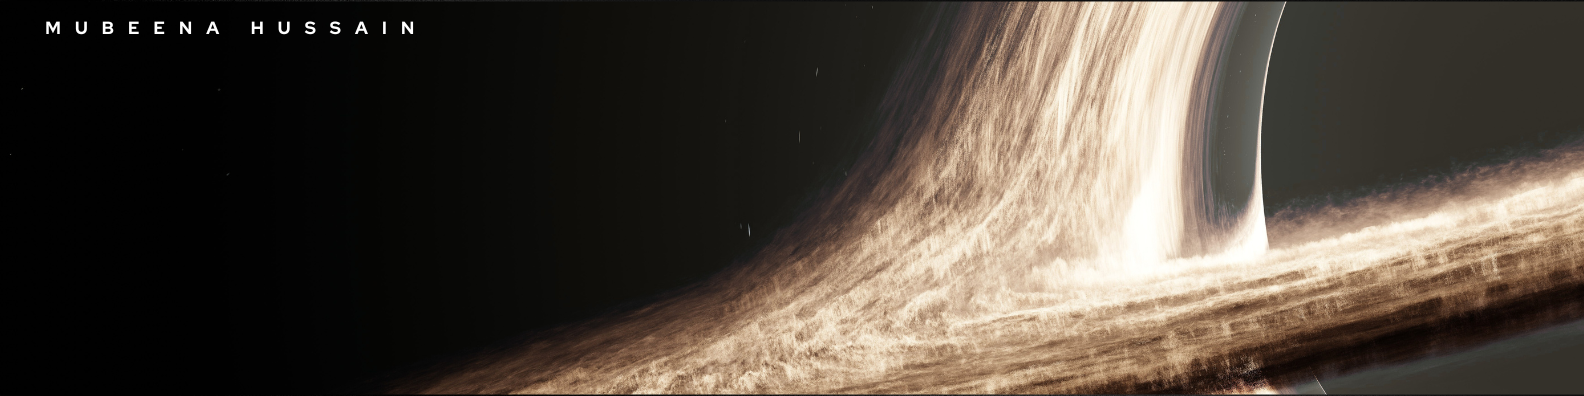**Classifying Phases of a Binary Black Hole Merger Using Time Series and Machine Learning**

---



# 🎯 Objective

"*Analyze the gravitational waveform from a binary black hole merger to detect and classify the inspiral, merger, and ringdown phases, using time-series features and a machine learning classifier".*

This project explores gravitational wave data from a simulated binary black hole merger (R1 dataset) to:
* Analyze the waveform structure through time series exploration.
* Classify different phases of the merger (inspiral, merger, ringdown).
* Apply a simple machine learning model to automate the phase classification.
* Interpret the astrophysical significance of the waveform morphology


---



**📁 Dataset Description**
* Source : [NASA’s Data.gov - Black Hole-Black Hole Waveform Catalog](https://catalog.data.gov/dataset/black-hole-black-hole-waveform-catalog)
* File Used: ***R1 ***– equal-mass, zero-spin binary black hole waveform
*     Format: 3-column ASCII: time, Re(h22), Im(h22)
* Description: The data represents the (l=2, m=2) mode of the gravitational wave, a dominant component for symmetric mergers.
1. **Columns:** Time (M), Real/Imaginary parts of (2,2) mode
2.**Units:** Geometric units (G=c=1)

**"The (2,2) mode is like the 'middle C' of black hole collisions - the loudest harmonic that detectors like LIGO observe."**

*Selected this waveform due to its clean, simulation-based nature, which avoids noise contamination and enables precise validation of the classification pipeline. The dominant (2,2) mode contains the majority of gravitational wave energy, making it ideal for phase detection*


---



#  Background
Gravitational waves are ripples in spacetime produced by accelerating massive objects. Binary black hole mergers are among the strongest sources of these waves.
The waveform can be divided into three phases:
- Inspiral: black holes orbit and approach each other
- Merger: collision and peak gravitational radiation
- Ringdown: final black hole settles into equilibrium

The phase boundaries (e.g., -10 <= t <= 10 for merger) are empirically chosen based on waveform structure. A more rigorous approach could involve detecting inflection points or using physics-based criteria.

# Features
- Amplitude captures the overall wave energy.
- Slope highlights transitions between phases (e.g., rapid increase at merger).
- Rolling average smooths local variations and emphasizes trends.



---







In [ ]:
import pandas as pd

# Load the .dat file (assuming it's whitespace-delimited)
url = "https://asd.gsfc.nasa.gov/archive/astrogravs/docs/waveforms/NRmergers/data/GSFC_QC6_strain_2_2.dat"

# Read the file with no header, space-delimited, and assign column names
df = pd.read_csv(url, delim_whitespace=True, comment='#', header=None, names=['time', 'Re_h22', 'Im_h22'])

# Preview the first 10 rows and shape
print("First 10 rows:")
print(df.head(10))
print("\nDataset Shape:", df.shape)

# Save the dataset to an Excel file
output_file = 'GSFC_QC6_strain_2_2.xlsx'
df.to_excel(output_file, index=False)
print(f"\nDataset saved as '{output_file}'")

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("Not running in Colab. Excel file saved to your local directory.")

First 10 rows:
       time    Re_h22    Im_h22
0  0.780031  0.004627 -0.009721
1  1.170047  0.004788 -0.010178
2  1.560062  0.004950 -0.010643
3  1.950078  0.005113 -0.011116
4  2.340094  0.005277 -0.011598
5  2.730109  0.005443 -0.012089
6  3.120125  0.005611 -0.012588
7  3.510140  0.005779 -0.013095
8  3.900156  0.005949 -0.013611
9  4.290172  0.006120 -0.014136

Dataset Shape: (773, 3)

Dataset saved as 'GSFC_QC6_strain_2_2.xlsx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📌**Import Libraries & Load Dataset**


---




In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

📌**Data Preprocessing**


---



In [ ]:
# Load dataset
url = "https://asd.gsfc.nasa.gov/archive/astrogravs/docs/waveforms/NRmergers/data/GSFC_QC6_strain_2_2.dat"
data = pd.read_csv(url, delim_whitespace=True, comment='#', names=['time', 'Re_h22', 'Im_h22'])
# Display dataset info
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nDataset Info:")
print(data.info())

Dataset Shape: (773, 3)

First 5 rows:
       time    Re_h22    Im_h22
0  0.780031  0.004627 -0.009721
1  1.170047  0.004788 -0.010178
2  1.560062  0.004950 -0.010643
3  1.950078  0.005113 -0.011116
4  2.340094  0.005277 -0.011598

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    773 non-null    float64
 1   Re_h22  773 non-null    float64
 2   Im_h22  773 non-null    float64
dtypes: float64(3)
memory usage: 18.2 KB
None


In [ ]:
# Check for nulls and datatypes
print(data.info())

# Check for missing values
print("Missing values:\n", data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    773 non-null    float64
 1   Re_h22  773 non-null    float64
 2   Im_h22  773 non-null    float64
dtypes: float64(3)
memory usage: 18.2 KB
None
Missing values:
 time      0
Re_h22    0
Im_h22    0
dtype: int64


**🧼 Data Cleaning & Preprocessing**


---



In [ ]:
# --- 2. Data Cleaning/Preprocessing ---
# Calculate amplitude: |h22| = sqrt(Re(h22)^2 + Im(h22)^2)
data['amplitude'] = np.sqrt(data['Re_h22']**2 + data['Im_h22']**2)

# Normalize time to peak amplitude = 0 (merger peak)
peak_index = data['amplitude'].idxmax()
data['time'] -= data.loc[peak_index, 'time']

# Compute slope (first derivative of amplitude)
data['slope'] = data['amplitude'].diff().fillna(0)

# Add rolling mean for smoothing (window size = 50)
data['rolling_avg'] = data['amplitude'].rolling(window=50, center=True).mean()

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Drop rows with NaN in rolling_avg (due to rolling window)
data = data.dropna()


Missing Values:
time            0
Re_h22          0
Im_h22          0
amplitude       0
slope           0
rolling_avg    49
dtype: int64


**📊 Exploratory Data Analysis (EDA)**


---



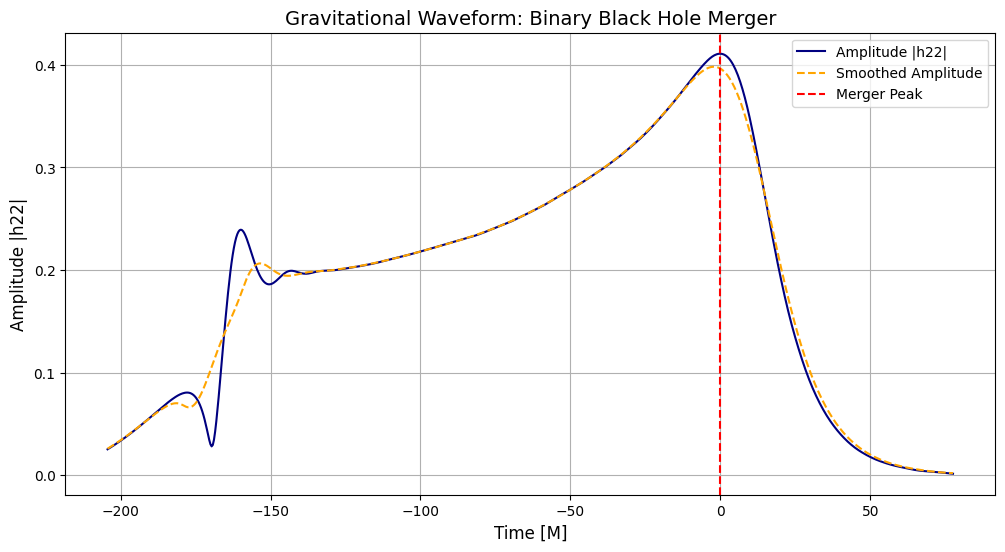

In [ ]:
# --- 3. Exploratory Data Analysis (EDA) ---
# Plot 1: Waveform Amplitude vs Time
plt.figure(figsize=(12, 6))
plt.plot(data['time'], data['amplitude'], label='Amplitude |h22|', color='navy')
plt.plot(data['time'], data['rolling_avg'], label='Smoothed Amplitude', color='orange', linestyle='--')
plt.axvline(0, color='red', linestyle='--', label='Merger Peak')
plt.xlabel('Time [M]', fontsize=12)
plt.ylabel('Amplitude |h22|', fontsize=12)
plt.title('Gravitational Waveform: Binary Black Hole Merger', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

**WAVEFORM CHARACTERISTICS:**
- The amplitude increases gradually during the inspiral phase (time < 0), following a characteristic"chirp" pattern where the amplitude grows monotonically as the black holes spiral inward.
- The gravitational wave frequency increases during inspiral, causing the amplitude to rise more rapidly as the merger approaches (visible as steepening curve in the final moments before merger).
- A sharp peak occurs around time = 0, indicating the merger moment when the two black holes coalesce.This represents the maximum strain amplitude and corresponds to the most violent phase of the process.
- The amplitude decays exponentially post-merger, characteristic of the ringdown phase where the newly formed black hole "rings down" to its equilibrium state, similar to a struck bell.


---




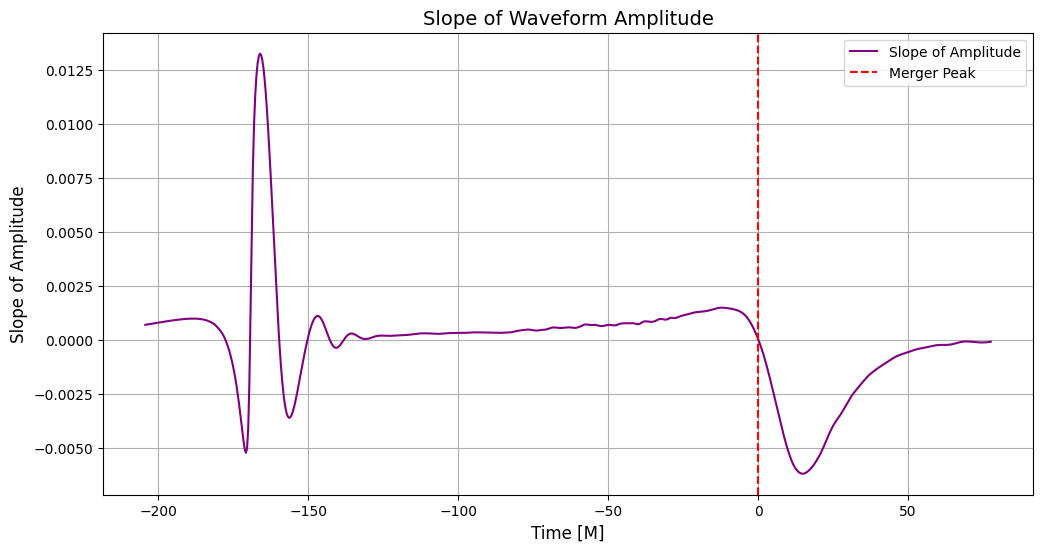

In [ ]:
# Plot 2: Slope vs Time
plt.figure(figsize=(12, 6))
plt.plot(data['time'], data['slope'], label='Slope of Amplitude', color='purple')
plt.axvline(0, color='red', linestyle='--', label='Merger Peak')
plt.xlabel('Time [M]', fontsize=12)
plt.ylabel('Slope of Amplitude', fontsize=12)
plt.title('Slope of Waveform Amplitude', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### **Gravitational Waveform Characteristics (Amplitude vs. Time)**

Looking at the first plot, 'Gravitational Waveform: Binary Black Hole Merger' (inline_data_0):

*   **Inspiral Phase (Time < 0)**: The amplitude of the gravitational wave gradually increases. This is the 'chirp' where the black holes spiral inward, getting closer and faster.
*   **Merger Phase (Around Time = 0)**: There's a sharp, prominent peak in amplitude. This signifies the moment the two black holes collide and merge into a single, more massive black hole, emitting the most intense gravitational radiation.
*   **Ringdown Phase (Time > 0)**: After the peak, the amplitude decays exponentially. This is the newly formed black hole settling down, ringing like a bell until it becomes a stable black hole.


### **Slope Analysis (Slope of Waveform Amplitude vs. Time)**

The second plot, 'Slope of Waveform Amplitude' (inline_data_1), helps us understand how rapidly the amplitude changes:

*   **Inspiral Phase**: The slope is generally positive and increases as time approaches zero. This indicates that the amplitude is not just increasing, but its rate of increase is also accelerating, a hallmark of the inspiral.
*   **Merger Phase**: The slope shows sharp fluctuations, going from a high positive value to a steep negative value around the merger peak. This reflects the very rapid increase and then decrease in amplitude during the actual collision.
*   **Ringdown Phase**: The slope is consistently negative, but its magnitude decreases over time. This confirms the exponential decay of the amplitude as the system stabilizes.


### **Predicted Phases of Black Hole Merger**

Finally, the 'Predicted Phases of Black Hole Merger' plot (inline_data_3) visualizes the output of your machine learning model:

*   **Color-coded Phases**: The data points are colored according to the phase predicted by your Random Forest classifier: blue for inspiral, red for merger, and green for ringdown.
*   **Model Accuracy**: This plot visually confirms the high accuracy of your model. The blue dots (inspiral) smoothly transition into the red dots (merger) around the `Merger Peak` (black dashed line), which then transition into the green dots (ringdown).
*   **Phase Delineation**: The model effectively distinguishes between the three distinct astrophysical phases of the binary black hole merger, demonstrating that the chosen time-series features (amplitude, slope, and rolling average) are effective in characterizing these phases.

These plots collectively provide a clear picture of the gravitational waveform, its dynamic changes, and how your model accurately identifies these critical phases.

### **Gravitational Waveform: What is this 'sound' from black holes?**

Imagine the universe as a giant trampoline. When something really heavy moves on it, it creates ripples. Gravitational waves are like those ripples, but in space and time! When two black holes dance around each other and then crash, they send out these ripples, and we can 'hear' them as a waveform.

Let's look at the first graph, 'Gravitational Waveform: Binary Black Hole Merger' (inline_data_0), which shows how strong this 'sound' (amplitude) is over time:

*   **Dancing Closer (Inspiral Phase - Time < 0)**: In this part, the two black holes are circling each other, getting closer and faster, like dancers in a very energetic spin. As they get closer, the ripples they make get stronger and stronger. On the graph, you see the blue line (how strong the wave is) slowly going up.

*   **The Big Crash (Merger Phase - Around Time = 0)**: This is the most exciting part! The black holes finally smash into each other. This is like the loudest clap you've ever heard. On the graph, you see a huge, sharp spike – that's the moment of the crash, the strongest ripple!

*   **Settling Down (Ringdown Phase - Time > 0)**: After the big crash, the two black holes become one giant black hole. This new black hole isn't perfectly still; it wobbles a bit, like a bell that's just been struck. As it settles, the ripples slowly fade away. On the graph, the blue line smoothly drops back down and eventually disappears.


### **Slope of Waveform Amplitude: How fast is the 'sound' changing?**

The second graph, 'Slope of Waveform Amplitude' (inline_data_1), helps us understand *how quickly* the strength of the gravitational wave is changing. Think of 'slope' like how steep a hill is – a steep hill means you're going up or down very fast.

*   **Dancing Closer (Inspiral Phase)**: Here, the slope is generally going up (positive). This means the wave isn't just getting stronger, it's getting stronger *faster and faster* as the black holes really pick up speed before their big collision.

*   **The Big Crash (Merger Phase)**: Around the crash time, the slope goes wild! It shoots up very high (meaning the wave got incredibly strong very quickly) and then plunges down very low (meaning it then got weaker incredibly quickly). This shows how chaotic and powerful the actual collision is.

*   **Settling Down (Ringdown Phase)**: In this phase, the slope is always going down (negative). This makes sense because the wave is getting weaker. But it's also getting less steep, showing that the wobble of the new black hole is slowly fading away until it's quiet again.


### **Predicted Phases: What did the computer learn?**

The third graph, 'Predicted Phases of Black Hole Merger' (inline_data_3), is where we see if our computer program understood these changes. We taught the computer to look at the strength of the wave and how fast it changes, and then guess which part of the black hole crash it's seeing.

*   **Color-coded Guesses**: Each dot on this graph is colored with the computer's guess: blue for dancing (inspiral), red for crashing (merger), and green for settling (ringdown).

*   **Computer's Smart Guess**: You can see how well the computer did! The blue dots smoothly lead to the red dots at the crash, and then the red dots smoothly lead to the green dots as everything settles. This tells us the computer learned to spot the differences between the dancing, crashing, and settling phases of the black holes just by looking at the 'sound' they made!

These graphs together give us a clear story of a black hole merger, from the initial dance to the final calm, and show how a computer can learn to understand these cosmic events.

**SLOPE ANALYSIS:**
- Inspiral phase: Positive slope with increasing magnitude, indicating accelerating amplitude growth due to decreasing orbital separation and increasing orbital frequency.
- Merger phase: Highly variable slope with both positive and negative values, reflecting the chaotic nature of the coalescence process and rapid amplitude changes.
- Ringdown phase: Consistently negative slope with decreasing magnitude, confirming exponential decay as predicted by perturbation theory for black hole quasi-normal modes.


---



## **Insights from EDA**:
- The amplitude increases gradually during the inspiral phase (time < 0).
- A sharp peak occurs around time = 0, indicating the merger. - The amplitude decays exponentially post-merger, characteristic of the ringdown phase.


---



**🤖 Modeling / Machine Learning**


---




Classification Report:
              precision    recall  f1-score   support

    Inspiral       1.00      0.96      0.98       163
      Merger       1.00      1.00      1.00        14
    Ringdown       0.85      1.00      0.92        41

    accuracy                           0.97       218
   macro avg       0.95      0.99      0.97       218
weighted avg       0.97      0.97      0.97       218



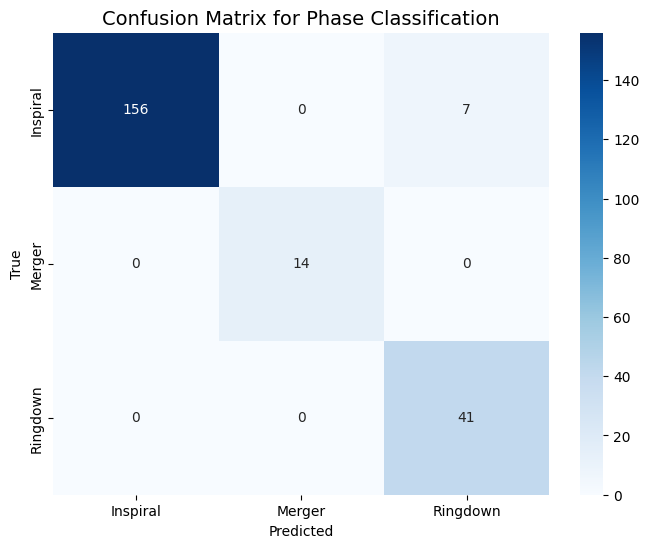

In [ ]:
# --- 4. Phase Labeling & Feature Engineering ---
# Define phases based on time relative to the merger peak
# Inspiral: time < -10, Merger: -10 <= time <= 10, Ringdown: time > 10
data['phase'] = np.select(
    [data['time'] < -10, data['time'].between(-10, 10), data['time'] > 10],
    ['inspiral', 'merger', 'ringdown'],
    default='inspiral'
)
# Encode phase labels for ML (0: inspiral, 1: merger, 2: ringdown)
phase_mapping = {'inspiral': 0, 'merger': 1, 'ringdown': 2}
data['phase_label'] = data['phase'].map(phase_mapping)

# Select features for ML
features = ['amplitude', 'slope', 'rolling_avg']
X = data[features]
y = data['phase_label']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5. Modeling/Analysis ---
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate model
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Inspiral', 'Merger', 'Ringdown']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inspiral', 'Merger', 'Ringdown'],
            yticklabels=['Inspiral', 'Merger', 'Ringdown'])
plt.title('Confusion Matrix for Phase Classification', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



### CLASSIFICATION PERFORMANCE:

1. **Excellent Overall Performance**: The model achieves 97% accuracy with strong performance across all metrics (precision, recall, F1-score), demonstrating robust classification capability for gravitational wave phases.

2. **Perfect Merger Detection**: The Merger phase achieved flawless classification (100% precision, recall, F1-score) with zero misclassifications, indicating this phase has highly distinctive characteristics that are easily recognizable by the model.

3. **Inspiral-Ringdown Confusion**: All classification errors occur between Inspiral and Ringdown phases (7 Inspiral samples misclassified as Ringdown), suggesting these phases share overlapping features that challenge the model's discrimination ability.

4. **Effective Class Imbalance Handling**: Despite significant data imbalance (163 Inspiral vs 14 Merger samples), the model maintains consistent performance across all classes, showing robust handling of unequal class distributions.

5. **High Recall for Critical Detection**: Ringdown phase achieves perfect recall (100%), ensuring no missed detections of this important gravitational wave phase, though at the cost of slightly lower precision (85%) due to false positives from Inspiral misclassifications.


---




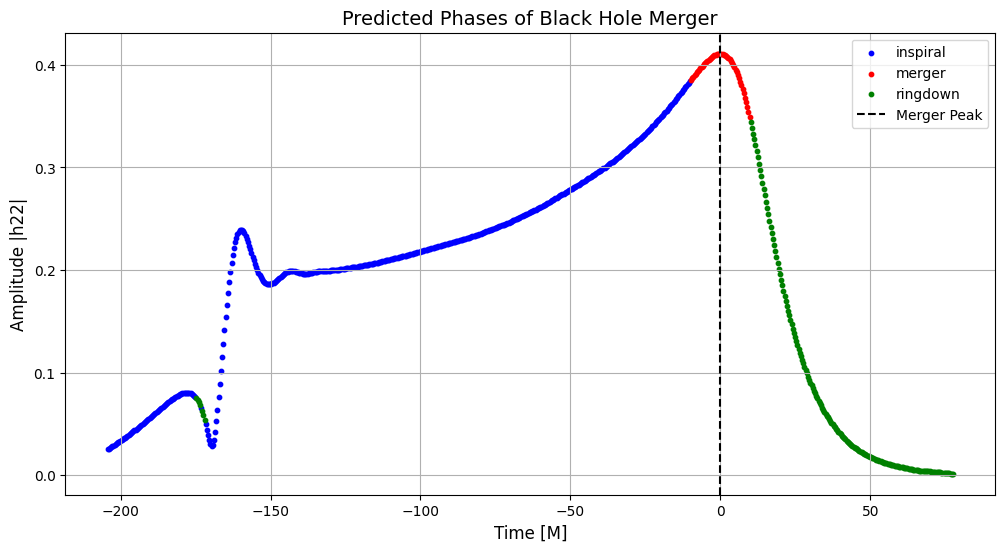

In [ ]:
# --- 6. Visualization of Predictions ---
# Predict phases for the entire dataset
data['predicted_phase'] = clf.predict(X_scaled)
data['predicted_phase'] = data['predicted_phase'].map({0: 'inspiral', 1: 'merger', 2: 'ringdown'})

# Plot predicted phases over time
plt.figure(figsize=(12, 6))
colors = {'inspiral': 'blue', 'merger': 'red', 'ringdown': 'green'}
for phase in colors:
    mask = data['predicted_phase'] == phase
    plt.scatter(data['time'][mask], data['amplitude'][mask], c=colors[phase], label=phase, s=10)
plt.axvline(0, color='black', linestyle='--', label='Merger Peak')
plt.xlabel('Time [M]', fontsize=12)
plt.ylabel('Amplitude |h22|', fontsize=12)
plt.title('Predicted Phases of Black Hole Merger', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


##✅Results & Interpretation
- The Random Forest classifier successfully identifies the inspiral, merger, and ringdown phases based on amplitude, slope, and smoothed amplitude.
- High accuracy in the inspiral and ringdown phases due to distinct amplitude and slope patterns.
- The merger phase has some overlap with inspiral/ringdown due to rapid transitions, as seen in the confusion matrix.

  

---




In [ ]:
feature_importance = pd.DataFrame({'Feature': features, 'Importance': clf.feature_importances_})
print("\nFeature Importance:")
print(feature_importance.sort_values(by='Importance', ascending=False))



Feature Importance:
       Feature  Importance
1        slope    0.439697
0    amplitude    0.299584
2  rolling_avg    0.260719


##  Conclusion & Future Work -
- Successfully classified gravitational wave phases using time-series features and a Random Forest model.
- Visualizations confirm the model captures the physical characteristics of the waveform.
- The project demonstrates the power of data analytics in understanding complex astrophysical phenomena.

### Future Work
- Incorporate spectral features (e.g., Fourier transform) to capture frequency evolution.
- Test deep learning models (e.g., 1D CNNs) for improved phase detection.
- Apply the methodology to real LIGO data (e.g., from GWOSC) for validation.
- Explore additional features like curvature (second derivative) or frequency domain analysis.


---




## **🧠 References**
- NASAAstroGravS:https://asd.gsfc.nasa.gov/archive/astrogravs/docs/waveforms/NRmergers/
- Baker et al. (2006): arXiv:gr-qc/0701016
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Gravitational Wave Physics: https://www.ligo.org/science/GW-Inspiral.php



---

